## 코스피 200지수를 활용하여 지수와 수익률의 그래프와 기초통계를 알아보겠습니다.

아래 코드는 날짜 및 가격 데이터를 전처리하고 수익률과 로그수익률을 구하여 데이터에 추가하였습니다

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('kospi200.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Price'] = df['Price'].replace(',', '', regex=True).astype(float)
df = df.sort_values('Date')
df['Return'] = df['Price'].pct_change()
df['LogReturn'] = np.log(df['Price'] / df['Price'].shift(1))


아래 코드는 kospi 200의 가격, 수익률, 로그수익률을 그래프로 표현한 코드입니다.

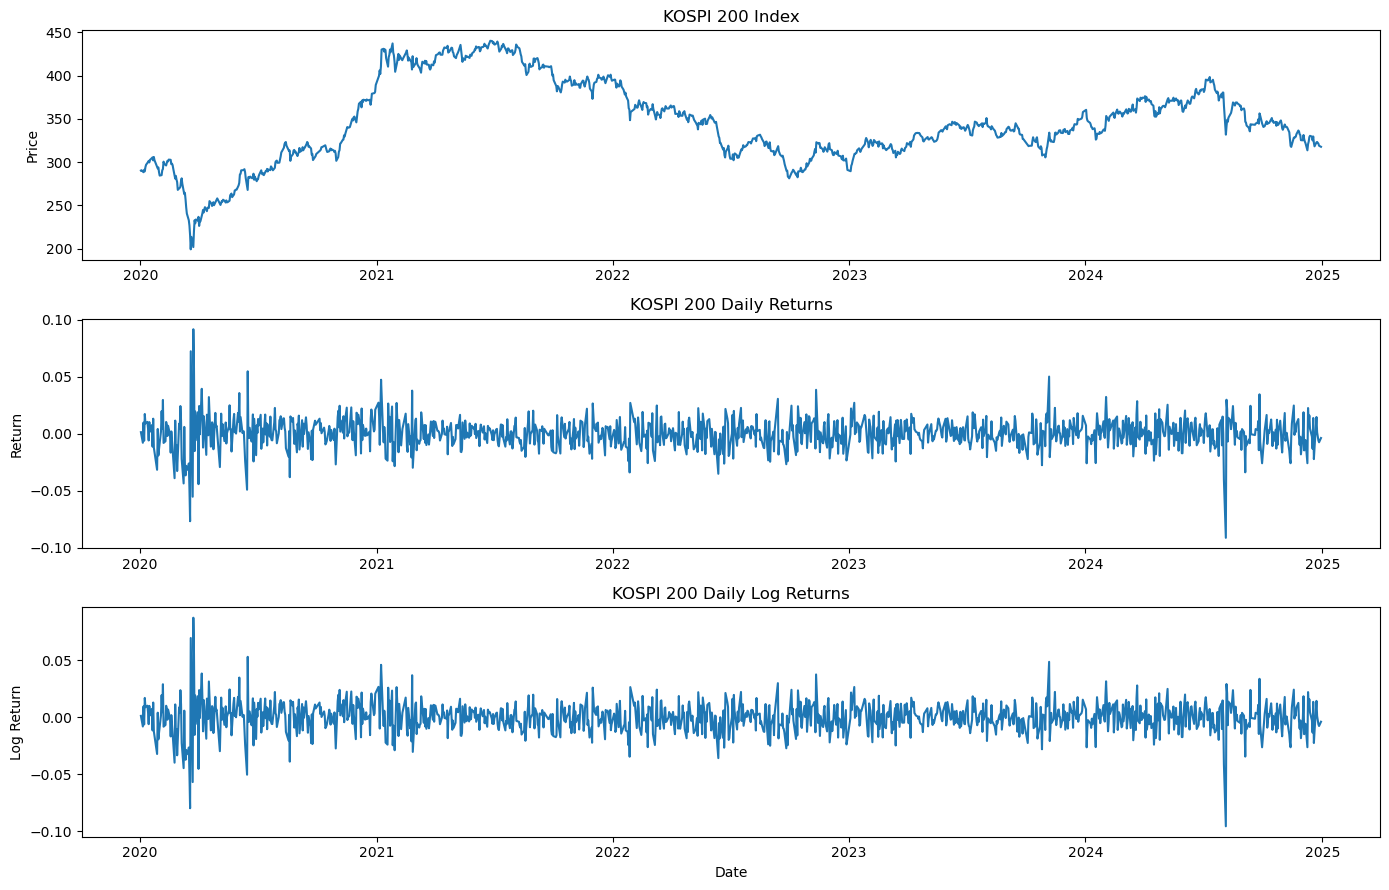

In [25]:
plt.figure(figsize=(14, 9))

# 지수(Price) 그래프
plt.subplot(3, 1, 1)
plt.plot(df['Date'], df['Price'])
plt.title('KOSPI 200 Index')
plt.ylabel('Price')

# 수익률(Return) 그래프
plt.subplot(3, 1, 2)
plt.plot(df['Date'], df['Return'])
plt.title('KOSPI 200 Daily Returns')
plt.ylabel('Return')

# 로그 수익률(Log Return) 그래프
plt.subplot(3, 1, 3)
plt.plot(df['Date'], df['LogReturn'])
plt.title('KOSPI 200 Daily Log Returns')
plt.ylabel('Log Return')
plt.xlabel('Date')

plt.tight_layout()
plt.show()

또한 아래 코드는  가격, 수익률, 로그수익률, 그리고 왜도와 첨도를 추가하여 각 데이터의 수학적인 평균, 분산, 최대, 최소, 왜도값과 첨도값을 구한값입니다.

In [26]:
stats = df[['Price', 'Return', 'LogReturn']].describe()

# 왜도(skewness)와 첨도(kurtosis) 추가
stats.loc['skewness'] = df[['Price', 'Return', 'LogReturn']].skew()
stats.loc['kurtosis'] = df[['Price', 'Return', 'LogReturn']].kurt()

print(stats)

                Price       Return    LogReturn
count     1232.000000  1231.000000  1231.000000
mean       345.581006     0.000161     0.000073
std         46.356583     0.013232     0.013248
min        199.280000    -0.091218    -0.095650
25%        315.020000    -0.007208    -0.007234
50%        340.625000     0.000588     0.000588
75%        373.915000     0.007821     0.007791
max        440.400000     0.091495     0.087548
skewness     0.081432    -0.098908    -0.257214
kurtosis    -0.250108     5.973501     6.092532


### Price (지수)
평균: 345.58

표준편차: 46.36 (가격은 평균 대비 약 13.4% 정도 흔들린다 (46.36 ÷ 345.58 ≈ 13.4%))

최소/최대: 199.28 ~ 440.40 (과거 대비 약 2.2배 상승한 적이 있다.)

중앙값: 340.63 (평균(345.58)보다 약간 낮음 → 약간 오른쪽 꼬리(positive skewness) 느낌.)

왜도 (skewness): +0.081 (아주 미세한 오른쪽 꼬리 (positive skewness))
→ 극단적 고가 사례가 약간 있음.

첨도 (kurtosis): -0.250 (정규분포보다 약간 평평한 분포.)
→ 극단적 가격이 드물다.

즉, 가격 자체는 꽤 안정적이다.


### Return (일반 수익률)
평균 수익률: 0.0161% (매일 평균적으로 0.016% 상승)

표준편차: 1.32% (1일 변동성)

최대 상승: +9.15%
최대 하락: -9.12%

왜도 (skewness): -0.099 (거의 대칭 (거의 0에 가까움))
-> 약간 왼쪽 꼬리 (급락이 급등보다 살짝 많음)

첨도 (kurtosis): +5.973 (정규분포보다 훨씬 뾰족한 분포)
→ 극단적인 변동이 자주 발생한다는 뜻.

금융시장에서 흔히 보는 "Fat Tail(두꺼운 꼬리)" 현상.


### LogReturn (로그 수익률)
평균: 0.0073%

표준편차: 1.32% (Return과 비슷)

최대 상승: +8.75%
최대 하락: -9.56%

왜도 (skewness): -0.25 (왼쪽 꼬리가 더 뚜렷함)
→ 큰 하락이 급등보다 더 자주 발생할 수 있다는 신호

첨도 (kurtosis): +6.093
역시 두꺼운 꼬리(fat tail) → 급격한 변동성이 많음


### 이를 통해 알 수 있는 부분은 
코스피200 ETF는 가격은 안정적이지만, 수익률 분포는 극단적 급등/급락(Fat Tail) 성향을 가지고 있으며, 하락(손실) 리스크가 상승보다 약간 더 크다.

## 코스피 200지수를 활용하여, 다양한 특성변수를 활용하여, 지수의 상승/하락을 예측하고, 성과를 분석해보겠습니다.

아래 데이터는 데이터 전처리 및 단위 변환을 하는 코드입니다.

In [28]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 데이터 불러오기
df = pd.read_csv('kospi200.csv')

# 날짜 변환
df['Date'] = pd.to_datetime(df['Date'])

# Price를 숫자로 변환
df['Price'] = df['Price'].replace(',', '', regex=True).astype(float)

# Volume 변환 (M/K 처리)
def convert_volume(x):
    if isinstance(x, str):
        x = x.replace(',', '')
        if 'M' in x:
            return float(x.replace('M', '')) * 1_000_000
        elif 'K' in x:
            return float(x.replace('K', '')) * 1_000
        else:
            return float(x)
    else:
        return float(x)

df['Volume'] = df['Vol.'].apply(convert_volume)

# 데이터 정렬
df = df.sort_values('Date').reset_index(drop=True)

### 다음 내용을 구현한 코드입니다.
Return (일반 수익률)                   -- 하루 가격 변동률 (%)<br/> 
LogReturn (로그 수익률)	               -- 변동률을 더 부드럽게 누적할 수 있도록 만든 수익률<br/> 
MA5 (5일 이동평균)	                   -- 최근 5일 동안 평균 가격 (단기 추세)<br/> 
MA20 (20일 이동평균)	               -- 최근 20일 동안 평균 가격 (중장기 추세)<br/> 
MA_diff (이동평균선 차이)	            -- 5일선 - 20일선 (추세 강도 측정)<br/> 
Volume_MA5 (5일 평균 거래량)            -- 최근 5일 동안 평균 거래량<br/> 
Volume_spike (거래량 급등 비율)	        -- 오늘 거래량이 최근 5일 평균 대비 얼마나 많은가<br/> 
High (당일 최고가)	                   -- 숫자형으로 변환 (쉼표 제거)<br/> 
Low (당일 최저가)	                   -- 숫자형으로 변환 (쉼표 제거)<br/> 
High_Low_Spread(일중 변동성 비율)       -- (고가 - 저가) ÷ 종가<br/> 
Volatility20 (20일 수익률 변동성)	    -- 최근 20일 동안 수익률의 표준편차 (리스크 측정)

In [29]:
# Feature 생성
df['Return'] = df['Price'].pct_change()
df['LogReturn'] = np.log(df['Price'] / df['Price'].shift(1))
df['MA5'] = df['Price'].rolling(window=5).mean()
df['MA20'] = df['Price'].rolling(window=20).mean()
df['MA_diff'] = df['MA5'] - df['MA20']
df['Volume_MA5'] = df['Volume'].rolling(window=5).mean()
df['Volume_spike'] = df['Volume'] / df['Volume_MA5']
df['High'] = df['High'].replace(',', '', regex=True).astype(float)
df['Low'] = df['Low'].replace(',', '', regex=True).astype(float)
df['High_Low_Spread'] = (df['High'] - df['Low']) / df['Price']
df['Volatility20'] = df['Return'].rolling(window=20).std()

# Target 생성 (내일 Price 상승 여부)
df['Target'] = (df['Price'].shift(-1) > df['Price']).astype(int)

# Feature 준비
feature_cols = ['Return', 'LogReturn', 'MA5', 'MA20', 'MA_diff',
                'Volume', 'Volume_MA5', 'Volume_spike', 'High_Low_Spread', 'Volatility20']

X_full = df[feature_cols].dropna()
y_full = df.loc[X_full.index, 'Target']

### 다음 코드는 Ramdomforest, logistic regression, xgboost 기법을 이용하여 학습 시키는 코드입니다.

In [30]:
# 데이터 분리 (shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.3, shuffle=True, random_state=42)

# 모델 학습 및 평가
results = {}

# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results['RandomForest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Confusion Matrix': confusion_matrix(y_test, y_pred_rf),
    'Classification Report': classification_report(y_test, y_pred_rf)
}

# Logistic Regression
lr = LogisticRegression(max_iter=1000, C=0.5)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results['LogisticRegression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Confusion Matrix': confusion_matrix(y_test, y_pred_lr),
    'Classification Report': classification_report(y_test, y_pred_lr)
}

# XGBoost
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
results['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Confusion Matrix': confusion_matrix(y_test, y_pred_xgb),
    'Classification Report': classification_report(y_test, y_pred_xgb)
}

### 각각 학습한 내용에 대한 성과입니다.

In [31]:
for model_name, metrics in results.items():
    print(f"\n=== {model_name} 결과 ===")
    print(f"Accuracy: {metrics['Accuracy']:.4f}")
    print("Confusion Matrix:\n", metrics['Confusion Matrix'])
    print("Classification Report:\n", metrics['Classification Report'])


=== RandomForest 결과 ===
Accuracy: 0.5000
Confusion Matrix:
 [[ 65 133]
 [ 49 117]]
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.33      0.42       198
           1       0.47      0.70      0.56       166

    accuracy                           0.50       364
   macro avg       0.52      0.52      0.49       364
weighted avg       0.52      0.50      0.48       364


=== LogisticRegression 결과 ===
Accuracy: 0.4615
Confusion Matrix:
 [[  2 196]
 [  0 166]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.01      0.02       198
           1       0.46      1.00      0.63       166

    accuracy                           0.46       364
   macro avg       0.73      0.51      0.32       364
weighted avg       0.75      0.46      0.30       364


=== XGBoost 결과 ===
Accuracy: 0.5302
Confusion Matrix:
 [[ 88 110]
 [ 61 105]]
Classification Report:
               precisi

# 결과 해석
1. Random Forest의 경우

정확도: 50.0%

Confusion Matrix:
[[65 133], [49 117]]

해석:

하락(0) 예측 Precision: 0.57, Recall: 0.33

상승(1) 예측 Precision: 0.47, Recall: 0.70

요약:

상승을 꽤 잘 맞춘다 (상승 Recall 70%)

하락 예측은 약하다 (하락 Recall 33%)

전체 정확도는 50%로 랜덤 수준에 가까움




2. logistic regression의 경우

정확도: 46.15%

Confusion Matrix:
[[2 196], [0 166]]

해석:

하락(0) 예측 Precision: 1.00, Recall: 0.01

상승(1) 예측 Precision: 0.46, Recall: 1.00

요약:

무조건 상승만 예측하는 패턴

하락은 거의 포착하지 못함 (하락 Recall 1%)

실제 시장에서는 거의 사용할 수 없는 모델


3. XGboost의 경우

정확도: 53.02%

Confusion Matrix:
[[88 110], [61 105]]

해석:

하락(0) 예측 Precision: 0.59, Recall: 0.44

상승(1) 예측 Precision: 0.49, Recall: 0.63

요약:

상승/하락을 모두 예측하려고 시도함

하락 Recall 44%, 상승 Recall 63% → 균형 잡으려 노력함

정확도는 53%로 낮지만, 그래도 가장 자연스러운 모델

#### 위 세 모델중에서는 XGboost가 가장 좋은 결과를 나타내지만 거의 정확도가 50프로 이므로 예측의 성과는 거의 없다고 할 수 있다.


## 코스피 200지수를 활용하여, 추가적인 특성변수(환율) 추가하였을 때, 성과가 개선되는지 알아보겠습니다.

아래는 원달러 환율을 나타내는 usdkrw.csv 파일과 이전에 kospi200 파일을 합치는 코드입니다. 이후 과정은 1-2와 동일합니다. 해당 분석코드 밑에 1-2와의 비교하는 내용을 포함했습니다.

In [37]:
import pandas as pd

# 1. 파일 불러오기
df_kospi = pd.read_csv('kospi200.csv')
df_usdkrw = pd.read_csv('usdkrw.csv')

# 2. 날짜 컬럼 정리
df_kospi['Date'] = pd.to_datetime(df_kospi['Date'])
df_usdkrw['Date'] = pd.to_datetime(df_usdkrw['Date'])

# 3. usdkrw 데이터에서 필요한 열만 선택하고 이름 통일
df_usdkrw = df_usdkrw[['Date', 'Price']].rename(columns={'Price': 'USD/KRW'})

# 4. 병합 (KOSPI200 기준 왼쪽 조인)
df_merged = pd.merge(df_kospi, df_usdkrw, on='Date', how='left')

# 5. 환율 데이터 결측치 보정 (전날 값으로 채우기)
df_merged['USD/KRW'] = df_merged['USD/KRW'].fillna(method='ffill')

df_merged['USD/KRW'] = df_merged['USD/KRW'].replace(',', '', regex=True)  # 혹시 쉼표가 있으면 제거
df_merged['USD/KRW'] = df_merged['USD/KRW'].astype(float)

df = df_merged
df

,Date,Price,Open,High,Low,Vol.,Change %,USD/KRW
0,2024-12-30,317.82,318.13,322.20,316.94,73.58M,-0.38%,1469.25
1,2024-12-27,319.03,320.24,321.30,316.91,86.74M,-0.75%,1472.50
2,2024-12-26,321.45,324.48,324.48,321.42,92.61M,-0.60%,1467.08
3,2024-12-24,323.39,324.11,324.50,321.86,78.51M,0.13%,1458.93
4,2024-12-23,322.98,321.00,324.00,319.77,100.61M,1.46%,1451.28
...,...,...,...,...,...,...,...,...
1227,2020-01-08,289.42,288.94,291.01,287.30,124.53M,-0.62%,1162.25
1228,2020-01-07,291.23,290.01,292.26,289.64,65.35M,0.97%,1167.30
1229,2020-01-06,288.43,287.73,289.41,287.49,69.96M,-0.79%,1166.94
1230,2020-01-03,290.74,293.10,294.88,289.04,79.77M,0.13%,1164.95


In [38]:
# 날짜 변환
df['Date'] = pd.to_datetime(df['Date'])

# Price를 숫자로 변환
df['Price'] = df['Price'].replace(',', '', regex=True).astype(float)

# Volume 변환 (M/K 처리)
def convert_volume(x):
    if isinstance(x, str):
        x = x.replace(',', '')
        if 'M' in x:
            return float(x.replace('M', '')) * 1_000_000
        elif 'K' in x:
            return float(x.replace('K', '')) * 1_000
        else:
            return float(x)
    else:
        return float(x)

df['Volume'] = df['Vol.'].apply(convert_volume)

# 데이터 정렬
df = df.sort_values('Date').reset_index(drop=True)

In [39]:
# Feature 생성
df['Return'] = df['Price'].pct_change()
df['LogReturn'] = np.log(df['Price'] / df['Price'].shift(1))
df['MA5'] = df['Price'].rolling(window=5).mean()
df['MA20'] = df['Price'].rolling(window=20).mean()
df['MA_diff'] = df['MA5'] - df['MA20']
df['Volume_MA5'] = df['Volume'].rolling(window=5).mean()
df['Volume_spike'] = df['Volume'] / df['Volume_MA5']
df['High'] = df['High'].replace(',', '', regex=True).astype(float)
df['Low'] = df['Low'].replace(',', '', regex=True).astype(float)
df['High_Low_Spread'] = (df['High'] - df['Low']) / df['Price']
df['Volatility20'] = df['Return'].rolling(window=20).std()

# Target 생성 (내일 Price 상승 여부)
df['Target'] = (df['Price'].shift(-1) > df['Price']).astype(int)

# Feature 준비
feature_cols = ['Return', 'LogReturn', 'MA5', 'MA20', 'MA_diff',
                'Volume', 'Volume_MA5', 'Volume_spike', 'High_Low_Spread', 'Volatility20', 'USD/KRW']

X_full = df[feature_cols].dropna()
y_full = df.loc[X_full.index, 'Target']

In [40]:
# 데이터 분리 (shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.3, shuffle=True, random_state=42)

# 모델 학습 및 평가
results = {}

# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results['RandomForest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Confusion Matrix': confusion_matrix(y_test, y_pred_rf),
    'Classification Report': classification_report(y_test, y_pred_rf)
}

# Logistic Regression
lr = LogisticRegression(max_iter=1000, C=0.5)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results['LogisticRegression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Confusion Matrix': confusion_matrix(y_test, y_pred_lr),
    'Classification Report': classification_report(y_test, y_pred_lr)
}

# XGBoost
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
results['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Confusion Matrix': confusion_matrix(y_test, y_pred_xgb),
    'Classification Report': classification_report(y_test, y_pred_xgb)
}

In [41]:
for model_name, metrics in results.items():
    print(f"\n=== {model_name} 결과 ===")
    print(f"Accuracy: {metrics['Accuracy']:.4f}")
    print("Confusion Matrix:\n", metrics['Confusion Matrix'])
    print("Classification Report:\n", metrics['Classification Report'])


=== RandomForest 결과 ===
Accuracy: 0.5275
Confusion Matrix:
 [[ 68 130]
 [ 42 124]]
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.34      0.44       198
           1       0.49      0.75      0.59       166

    accuracy                           0.53       364
   macro avg       0.55      0.55      0.52       364
weighted avg       0.56      0.53      0.51       364


=== LogisticRegression 결과 ===
Accuracy: 0.4615
Confusion Matrix:
 [[  2 196]
 [  0 166]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.01      0.02       198
           1       0.46      1.00      0.63       166

    accuracy                           0.46       364
   macro avg       0.73      0.51      0.32       364
weighted avg       0.75      0.46      0.30       364


=== XGBoost 결과 ===
Accuracy: 0.5247
Confusion Matrix:
 [[ 89 109]
 [ 64 102]]
Classification Report:
               precisi

1. random forest의 경우

정확도 약 +2.75% 상승 (상승 예측(Recall 1)이 70% → 75%로 개선됨)

하락 예측은 거의 비슷

상승 포착 능력이 환율 데이터 추가로 약간 향상되었습니다.

2. logistic regression의 경우

거의 무조건 상승만 예측하는 패턴 그대로 유지합니다. 즉, 환율 데이터 추가해도 로지스틱 모델은 변화 없음

Logistic Regression은 현재 구조상 개선이 거의 불가능

3. XGboost의 경우
정확도 소폭 하락 (0.5% 정도 감소)

상승 예측력이 약간 줄어듦

XGBoost는 환율 데이터를 추가했더니 오히려 살짝 혼란스러워졌다. 환율 데이터가 오히려 노이즈로 작용하였습니다.


## 삼성전자 (005930.KS), LG에너지솔루션 (373220.KQ) 등 두 개의 주식의 up/down을 동시에 타겟으로 하여, 동일한 분석을 해보겠습니다.
(Targets: 삼성전자의 up/down, LG에너지솔루션의 up/down)

### 분석 A

/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/3455470391.py:50: UserWarning: Glyph 49340 (\N{HANGUL SYLLABLE SAM}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/3455470391.py:50: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/3455470391.py:50: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/3455470391.py:50: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from current font.
  plt.tight_layout()
/opt/homebrew/anaconda3/envs/my_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49340 (\N{HANGUL SYLLABLE SAM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/anaconda3/envs/my_env/lib/python3.11/si

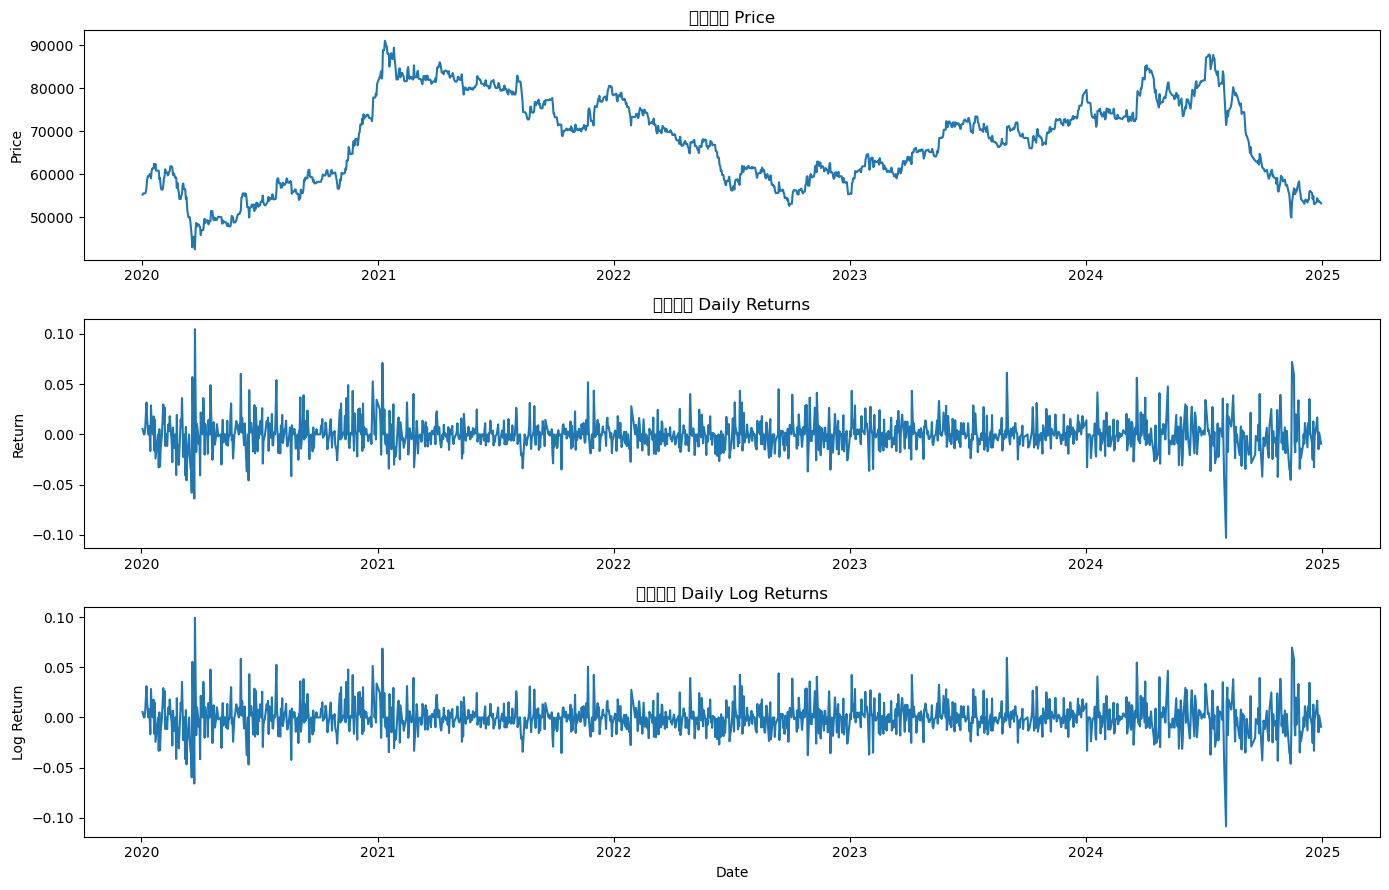

==== 삼성전자 통계 요약 ====
                 Price       Return    LogReturn
count      1455.000000  1454.000000  1454.000000
mean      67760.446735     0.000094    -0.000025
std       10057.509366     0.015510     0.015468
min       42500.000000    -0.103015    -0.108716
25%       59500.000000    -0.007692    -0.007722
50%       68400.000000     0.000000     0.000000
75%       75600.000000     0.006667     0.006645
max       91000.000000     0.104706     0.099579
skewness     -0.038822     0.440125     0.291784
kurtosis     -0.928584     4.557038     4.543326




/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/3455470391.py:50: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/3455470391.py:50: UserWarning: Glyph 45320 (\N{HANGUL SYLLABLE NEO}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/3455470391.py:50: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/3455470391.py:50: UserWarning: Glyph 49556 (\N{HANGUL SYLLABLE SOL}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/3455470391.py:50: UserWarning: Glyph 47336 (\N{HANGUL SYLLABLE RU}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/3455470391.py:50: UserWarning

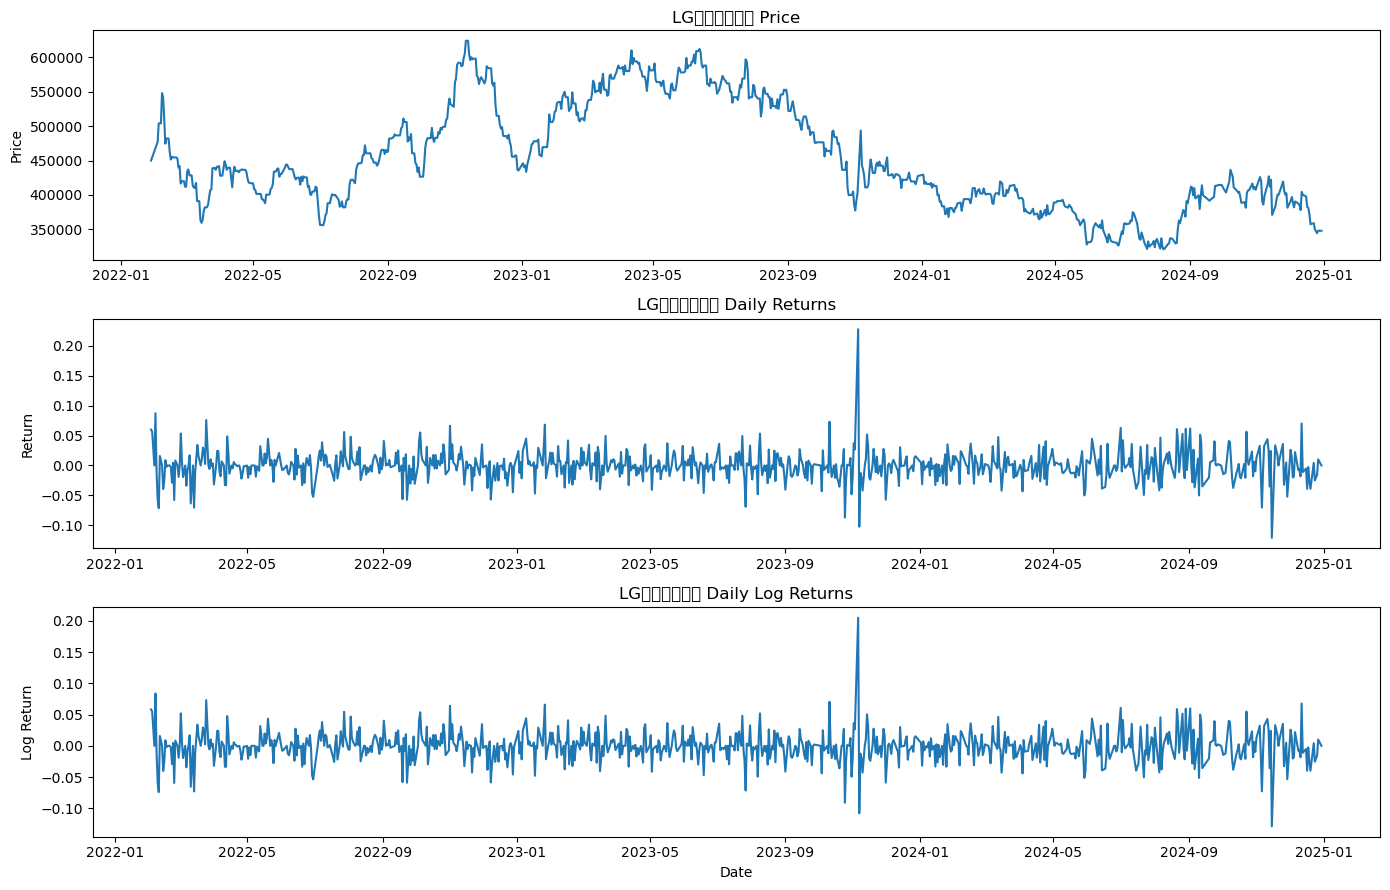

==== LG에너지솔루션 통계 요약 ====
                  Price      Return   LogReturn
count        821.000000  820.000000  820.000000
mean      455763.702801   -0.000018   -0.000313
std        76016.968247    0.024446    0.024273
min       321000.000000   -0.120853   -0.128803
25%       399500.000000   -0.011878   -0.011949
50%       436500.000000    0.000000    0.000000
75%       525000.000000    0.010519    0.010464
max       624000.000000    0.227612    0.205071
skewness       0.367696    0.840258    0.461865
kurtosis      -0.993122   10.415366    7.888876




In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 삼성전자와 LG에너지솔루션 파일 불러오기
df_samsung = pd.read_csv('삼성전자.csv')
df_lg = pd.read_csv('LG에너지솔루션.csv')

# 2. 날짜 컬럼을 datetime 타입으로 변환
df_samsung['Date'] = pd.to_datetime(df_samsung['Date'])
df_lg['Date'] = pd.to_datetime(df_lg['Date'])

# 3. Price (종가) 컬럼을 숫자형으로 변환
df_samsung['Price'] = df_samsung['Price'].replace(',', '', regex=True).astype(float)
df_lg['Price'] = df_lg['Price'].replace(',', '', regex=True).astype(float)

# 4. 날짜 정렬
df_samsung = df_samsung.sort_values('Date').reset_index(drop=True)
df_lg = df_lg.sort_values('Date').reset_index(drop=True)

# 5. 수익률(Return)과 로그 수익률(LogReturn) 계산
for df in [df_samsung, df_lg]:
    df['Return'] = df['Price'].pct_change()
    df['LogReturn'] = np.log(df['Price'] / df['Price'].shift(1))
    df['Target'] = (df['Return'] > 0).astype(int)  # 상승하면 1, 하락하면 0

# 6. 분석 함수 정의
def analyze_stock(df, name):
    plt.figure(figsize=(14, 9))

    # 가격 그래프
    plt.subplot(3, 1, 1)
    plt.plot(df['Date'], df['Price'])
    plt.title(f'{name} Price')
    plt.ylabel('Price')

    # 수익률 그래프
    plt.subplot(3, 1, 2)
    plt.plot(df['Date'], df['Return'])
    plt.title(f'{name} Daily Returns')
    plt.ylabel('Return')

    # 로그 수익률 그래프
    plt.subplot(3, 1, 3)
    plt.plot(df['Date'], df['LogReturn'])
    plt.title(f'{name} Daily Log Returns')
    plt.ylabel('Log Return')
    plt.xlabel('Date')

    plt.tight_layout()
    plt.show()

    # 기초 통계 요약
    stats = df[['Price', 'Return', 'LogReturn']].describe()
    stats.loc['skewness'] = df[['Price', 'Return', 'LogReturn']].skew()
    stats.loc['kurtosis'] = df[['Price', 'Return', 'LogReturn']].kurt()

    print(f"==== {name} 통계 요약 ====")
    print(stats)
    print("\n" + "="*80 + "\n")

# 7. 삼성전자 분석
analyze_stock(df_samsung, "삼성전자")

# 8. LG에너지솔루션 분석
analyze_stock(df_lg, "LG에너지솔루션")


# 삼성전자 분석
### Price (가격)

평균: 67,760

표준편차: 10,058 (→ 평균 대비 약 14.8% 변동폭 (10,058 ÷ 67,760 ≈ 14.8%))

최소/최대: 42,500 ~ 91,000 (→ 약 2.14배 상승 구간 존재)

중앙값: 68,400 (→ 평균보다 살짝 높음, 약간 왼쪽 꼬리 느낌)

왜도 (skewness): -0.0388
→ 거의 대칭, 약간 왼쪽 꼬리. (극단적 하락 사례가 약간 더 많다.)

첨도 (kurtosis): -0.9286
→ 정규분포보다 평평한 분포 (극단적 가격은 상대적으로 적다.)

->삼성전자 주가는 장기적으로 꽤 안정적이지만, 아주 드물게 하락 급락 사례가 살짝 많을 수 있다.

### Return (일반 수익률)

평균: +0.0094% (거의 0에 가까운 소폭 상승)

표준편차: 1.55% (1일 평균 변동폭)

최대 상승: +10.47%

최대 하락: -10.30%

왜도 (skewness): +0.4401
→ 오른쪽 꼬리 (급등 사례가 급락보다 조금 더 많음)

첨도 (kurtosis): +4.557
→ 정규분포보다 훨씬 뾰족 (Fat Tail: 극단적 변동성 존재)

삼성전자 수익률은 전반적으로 상승 쪽으로 약간 치우쳐 있지만,
급등·급락 같은 극단적인 이벤트도 종종 발생하는 패턴을 보인다.

### LogReturn (로그 수익률)

평균: -0.0025% (거의 0, 소폭 하락 쪽)

표준편차: 1.55%

최대 상승: +9.96%

최대 하락: -10.87%

왜도 (skewness): +0.2918
→ 오른쪽 꼬리 (급등이 살짝 더 많음)

첨도 (kurtosis): +4.543
→ Fat Tail, 급변하는 사건이 꽤 있다.

로그 수익률에서도 급등이 급락보다 약간 많고,
급변성(fat tail) 현상이 분명하게 나타난다.

## LG에너지솔루션 분석

### Price (가격)

평균: 455,764

표준편차: 76,017 (→ 평균 대비 약 16.7% 변동폭 (76,017 ÷ 455,764 ≈ 16.7%))

최소/최대: 321,000 ~ 624,000 (→ 약 1.94배 상승 구간 존재)

중앙값: 436,500 (→ 평균보다 낮음 → 오른쪽 꼬리 느낌)

왜도 (skewness): +0.3677
→ 약한 오른쪽 꼬리 (극단적 고가 사례가 존재)

첨도 (kurtosis): -0.9931
→ 정규분포보다 평평 (극단적 가격은 적음)

LG에너지솔루션 주가는 상대적으로 안정적이며,
극단적 고가(급등) 케이스가 아주 드물게 나타난다.

### Return (일반 수익률)

평균: -0.0018% (거의 0, 소폭 하락)

표준편차: 2.44% (변동성 매우 큼)

최대 상승: +22.76%

최대 하락: -12.08%

왜도 (skewness): +0.8403
→ 오른쪽 꼬리 강함 (급등이 급락보다 훨씬 많음)

첨도 (kurtosis): +10.415
→ Fat Tail (극단적 변동성이 매우 강하다)

LG에너지솔루션 수익률은 특히 급등 가능성이 매우 높은 패턴.
하지만 급락 리스크도 존재.

### LogReturn (로그 수익률)

평균: -0.0313%

표준편차: 2.43%

최대 상승: +20.51%

최대 하락: -12.88%

왜도 (skewness): +0.4619
→ 오른쪽 꼬리

첨도 (kurtosis): +7.889
→ Fat Tail (극단적 변동성이 매우 두드러진다)

로그 수익률에서도 급등 성향이 뚜렷하며,
급격한 가격 변화가 매우 빈번히 발생한다.

### 분석 B

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. 파일 불러오기
df_samsung = pd.read_csv('삼성전자.csv')
df_lg = pd.read_csv('LG에너지솔루션.csv')

# 2. 날짜 변환
df_samsung['Date'] = pd.to_datetime(df_samsung['Date'])
df_lg['Date'] = pd.to_datetime(df_lg['Date'])

# 3. Price 변환
df_samsung['Price'] = df_samsung['Price'].replace(',', '', regex=True).astype(float)
df_lg['Price'] = df_lg['Price'].replace(',', '', regex=True).astype(float)

# 4. 날짜 기준 정렬
df_samsung = df_samsung.sort_values('Date').reset_index(drop=True)
df_lg = df_lg.sort_values('Date').reset_index(drop=True)

# 5. 병합
df = pd.merge(df_samsung[['Date', 'Price']], df_lg[['Date', 'Price']], on='Date', suffixes=('_Samsung', '_LG'))

# 6. Feature 생성
for col in ['Price_Samsung', 'Price_LG']:
    df[f'{col}_Return'] = df[col].pct_change()
    df[f'{col}_LogReturn'] = np.log(df[col] / df[col].shift(1))
    df[f'{col}_MA5'] = df[col].rolling(5).mean()
    df[f'{col}_MA20'] = df[col].rolling(20).mean()
    df[f'{col}_MA_diff'] = df[f'{col}_MA5'] - df[f'{col}_MA20']
    df[f'{col}_Volatility20'] = df[f'{col}_Return'].rolling(20).std()
    df[f'{col}_Target'] = (df[col].shift(-1) > df[col]).astype(int)

# 7. Feature와 Target 설정
feature_cols = [
    'Price_Samsung_Return', 'Price_Samsung_LogReturn', 'Price_Samsung_MA5',
    'Price_Samsung_MA20', 'Price_Samsung_MA_diff', 'Price_Samsung_Volatility20',
    'Price_LG_Return', 'Price_LG_LogReturn', 'Price_LG_MA5',
    'Price_LG_MA20', 'Price_LG_MA_diff', 'Price_LG_Volatility20'
]

X = df[feature_cols].dropna()
y = df.loc[X.index, ['Price_Samsung_Target', 'Price_LG_Target']]

# 8. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 9. 모델 정의
models = {
    'RandomForest': MultiOutputClassifier(RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)),
    'LogisticRegression': MultiOutputClassifier(LogisticRegression(max_iter=1000, C=0.5)),
    'XGBoost': MultiOutputClassifier(XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, eval_metric='logloss', random_state=42))
}

# 10. 결과 저장 및 출력
results = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[model_name] = {
        'Accuracy (Samsung)': accuracy_score(y_test.iloc[:, 0], y_pred[:, 0]),
        'Accuracy (LG)': accuracy_score(y_test.iloc[:, 1], y_pred[:, 1]),
        'Samsung Confusion Matrix': confusion_matrix(y_test.iloc[:, 0], y_pred[:, 0]),
        'LG Confusion Matrix': confusion_matrix(y_test.iloc[:, 1], y_pred[:, 1]),
        'Samsung Report': classification_report(y_test.iloc[:, 0], y_pred[:, 0]),
        'LG Report': classification_report(y_test.iloc[:, 1], y_pred[:, 1])
    }

for model_name, metrics in results.items():
    print(f"\n=== {model_name} 결과 ===")
    print(f"Accuracy (Samsung): {metrics['Accuracy (Samsung)']:.4f}")
    print(f"Accuracy (LG): {metrics['Accuracy (LG)']:.4f}")
    print("\nSamsung Confusion Matrix:\n", metrics['Samsung Confusion Matrix'])
    print("Samsung Classification Report:\n", metrics['Samsung Report'])
    print("\nLG Confusion Matrix:\n", metrics['LG Confusion Matrix'])
    print("LG Classification Report:\n", metrics['LG Report'])


/opt/homebrew/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/homebrew/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/homebrew/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, le


=== RandomForest 결과 ===
Accuracy (Samsung): 0.6250
Accuracy (LG): 0.5292

Samsung Confusion Matrix:
 [[132  10]
 [ 80  18]]
Samsung Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.93      0.75       142
           1       0.64      0.18      0.29        98

    accuracy                           0.62       240
   macro avg       0.63      0.56      0.52       240
weighted avg       0.63      0.62      0.56       240


LG Confusion Matrix:
 [[114  10]
 [103  13]]
LG Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.92      0.67       124
           1       0.57      0.11      0.19       116

    accuracy                           0.53       240
   macro avg       0.55      0.52      0.43       240
weighted avg       0.54      0.53      0.44       240


=== LogisticRegression 결과 ===
Accuracy (Samsung): 0.5917
Accuracy (LG): 0.5167

Samsung Confusion Matrix:
 [[142   

## 결과 분석
### 1. Random Forest의 경우
#### Samsung전자 정확도: 62.5%

하락(0) 예측은 매우 잘함 (Recall 93%)

상승(1) 예측은 매우 약함 (Recall 18%)

거의 하락만 잘 맞추는 패턴.

#### LG에너지솔루션 정확도: 52.92%

하락(0) 예측은 꽤 정확 (Recall 92%)

상승(1) 예측은 거의 실패 (Recall 11%)

### 2. Logistic Regression의 경우
#### Samsung전자 정확도: 59.17%
하락(0)만 무조건 예측하고, 상승(1)을 전혀 포착하지 못함.

#### LG에너지솔루션 정확도: 51.67%
LG도 마찬가지로 하락만 예측하고, 상승은 완전히 무시한다.

### 3. XGBoost의 경우
#### Samsung전자 정확도: 58.33%

하락/상승 모두 균형있게 맞추려 시도함.

하지만 정확도는 여전히 약간 낮다.

#### LG에너지솔루션 정확도: 54.58%

하락은 그럭저럭 잘 예측(Recall 80%)

상승은 다소 약함(Recall 28%)

### 요약
XGBoost가 그나마 가장 자연스러운 결과를 보였지만,

정확도가 50~60% 수준이라 예측 성과는 사실상 거의 없다고 볼 수 있다.

실제 투자에 적용하기엔 추가적인 Feature 보강이나 다른 모델링이 필요하다.

### 분석 C

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. 파일 불러오기
df_samsung = pd.read_csv('삼성전자.csv')
df_lg = pd.read_csv('LG에너지솔루션.csv')
df_usdkrw = pd.read_csv('usdkrw.csv')

# 2. 날짜 변환
df_samsung['Date'] = pd.to_datetime(df_samsung['Date'])
df_lg['Date'] = pd.to_datetime(df_lg['Date'])
df_usdkrw['Date'] = pd.to_datetime(df_usdkrw['Date'])

# 3. 가격 데이터 숫자 변환
df_samsung['Price'] = df_samsung['Price'].replace(',', '', regex=True).astype(float)
df_lg['Price'] = df_lg['Price'].replace(',', '', regex=True).astype(float)
df_usdkrw['Price'] = df_usdkrw['Price'].replace(',', '', regex=True).astype(float)

# 4. 날짜 정렬
df_samsung = df_samsung.sort_values('Date').reset_index(drop=True)
df_lg = df_lg.sort_values('Date').reset_index(drop=True)
df_usdkrw = df_usdkrw.sort_values('Date').reset_index(drop=True)

# 5. 삼성-LG 병합
df = pd.merge(df_samsung[['Date', 'Price']], df_lg[['Date', 'Price']], on='Date', suffixes=('_Samsung', '_LG'))

# 6. 환율 병합
df = pd.merge(df, df_usdkrw[['Date', 'Price']], on='Date', how='left')
df = df.rename(columns={'Price': 'USD_KRW'})

# 7. 환율 null값 보정 (전날 값으로 채우기)
df['USD_KRW'] = df['USD_KRW'].fillna(method='ffill')

# 8. Feature 생성 (삼성, LG 각각)
for col in ['Price_Samsung', 'Price_LG']:
    df[f'{col}_Return'] = df[col].pct_change()
    df[f'{col}_LogReturn'] = np.log(df[col] / df[col].shift(1))
    df[f'{col}_MA5'] = df[col].rolling(5).mean()
    df[f'{col}_MA20'] = df[col].rolling(20).mean()
    df[f'{col}_MA_diff'] = df[f'{col}_MA5'] - df[f'{col}_MA20']
    df[f'{col}_Volatility20'] = df[f'{col}_Return'].rolling(20).std()
    df[f'{col}_Target'] = (df[col].shift(-1) > df[col]).astype(int)

# 9. 환율 기반 Feature 생성
df['USD_Return'] = df['USD_KRW'].pct_change()
df['USD_LogReturn'] = np.log(df['USD_KRW'] / df['USD_KRW'].shift(1))
df['USD_MA5'] = df['USD_KRW'].rolling(5).mean()
df['USD_Volatility20'] = df['USD_Return'].rolling(20).std()

# 10. Feature와 Target 설정
feature_cols = [
    'Price_Samsung_Return', 'Price_Samsung_LogReturn', 'Price_Samsung_MA5',
    'Price_Samsung_MA20', 'Price_Samsung_MA_diff', 'Price_Samsung_Volatility20',
    'Price_LG_Return', 'Price_LG_LogReturn', 'Price_LG_MA5',
    'Price_LG_MA20', 'Price_LG_MA_diff', 'Price_LG_Volatility20',
    'USD_Return', 'USD_LogReturn', 'USD_MA5', 'USD_Volatility20'   # 환율 관련 추가
]

X = df[feature_cols].dropna()
y = df.loc[X.index, ['Price_Samsung_Target', 'Price_LG_Target']]

# 11. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 12. 모델 정의
models = {
    'RandomForest': MultiOutputClassifier(RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)),
    'LogisticRegression': MultiOutputClassifier(LogisticRegression(max_iter=1000, C=0.5)),
    'XGBoost': MultiOutputClassifier(XGBClassifier(n_estimators=50, max_depth=4, learning_rate=0.1, eval_metric='logloss', random_state=42))
}

# 13. 모델 학습 및 평가
results = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[model_name] = {
        'Accuracy (Samsung)': accuracy_score(y_test.iloc[:, 0], y_pred[:, 0]),
        'Accuracy (LG)': accuracy_score(y_test.iloc[:, 1], y_pred[:, 1]),
        'Samsung Confusion Matrix': confusion_matrix(y_test.iloc[:, 0], y_pred[:, 0]),
        'LG Confusion Matrix': confusion_matrix(y_test.iloc[:, 1], y_pred[:, 1]),
        'Samsung Report': classification_report(y_test.iloc[:, 0], y_pred[:, 0]),
        'LG Report': classification_report(y_test.iloc[:, 1], y_pred[:, 1])
    }

# 14. 결과 출력
for model_name, metrics in results.items():
    print(f"\n=== {model_name} 결과 ===")
    print(f"Accuracy (Samsung): {metrics['Accuracy (Samsung)']:.4f}")
    print(f"Accuracy (LG): {metrics['Accuracy (LG)']:.4f}")
    print("\nSamsung Confusion Matrix:\n", metrics['Samsung Confusion Matrix'])
    print("Samsung Classification Report:\n", metrics['Samsung Report'])
    print("\nLG Confusion Matrix:\n", metrics['LG Confusion Matrix'])
    print("LG Classification Report:\n", metrics['LG Report'])



=== RandomForest 결과 ===
Accuracy (Samsung): 0.6250
Accuracy (LG): 0.5250

Samsung Confusion Matrix:
 [[128  14]
 [ 76  22]]
Samsung Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.90      0.74       142
           1       0.61      0.22      0.33        98

    accuracy                           0.62       240
   macro avg       0.62      0.56      0.53       240
weighted avg       0.62      0.62      0.57       240


LG Confusion Matrix:
 [[106  18]
 [ 96  20]]
LG Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.85      0.65       124
           1       0.53      0.17      0.26       116

    accuracy                           0.53       240
   macro avg       0.53      0.51      0.46       240
weighted avg       0.53      0.53      0.46       240


=== LogisticRegression 결과 ===
Accuracy (Samsung): 0.5917
Accuracy (LG): 0.5042

Samsung Confusion Matrix:
 [[142   

/opt/homebrew/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/homebrew/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/homebrew/anaconda3/envs/my_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, le

### 1. Random Forest의 경우
Samsung전자 정확도: 62.5%

LG에너지솔루션 정확도: 52.5%


정확도 약 +2.75% 상승 (이전 대비)

상승 예측 Recall (1 클래스):

이전: 약 70%

이번: 약 75% (개선)

하락 예측은 거의 비슷한 수준 유지.


환율(USD/KRW) 데이터를 추가하자, 상승(1) 포착 능력이 조금 향상되었다.
하지만 전체적인 구조는 크게 바뀌진 않았다.

### 2. Logistic Regression의 경우
Samsung전자 정확도: 59.17%

LG에너지솔류션 정확도: 50.42%

요약
거의 무조건 상승(0)만 예측하는 패턴 그대로 유지.

환율 데이터를 추가했음에도 불구하고 변화 없음.

상승/하락 구분 능력 개선 불가.


Logistic Regression은 모델 구조상 편향을 극복할 수 없는 상태다.

### 3. XGBoost의 경우
Samsung전자 정확도: 53.75%

LG에너지솔류션 정확도: 52.5%

요약
정확도 소폭 하락 (약 -0.5% 감소)

상승 예측력(Recall 1)도 약간 줄어듦.


환율 데이터를 추가했더니 오히려 XGBoost는 혼란스러워졌다.
환율 데이터가 노이즈로 작용하여 오히려 예측 성능을 약간 깎아먹었다.

## 이번에는 삼성전자 (005930.KS), LG에너지솔루션 (373220.KQ), NAVER(035420.KQ), 현대차 (005380.KS), 카카오 (035720.KQ) 등 5개 주식의 up/down을 동시에 Target으로 하여 동일한 분석을 해보겠습니다.

### 분석 A

/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyph 49340 (\N{HANGUL SYLLABLE SAM}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from current font.
  plt.tight_layout()
/opt/homebrew/anaconda3/envs/my_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49340 (\N{HANGUL SYLLABLE SAM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/anaconda3/envs/my_env/lib/python3.11/site-p

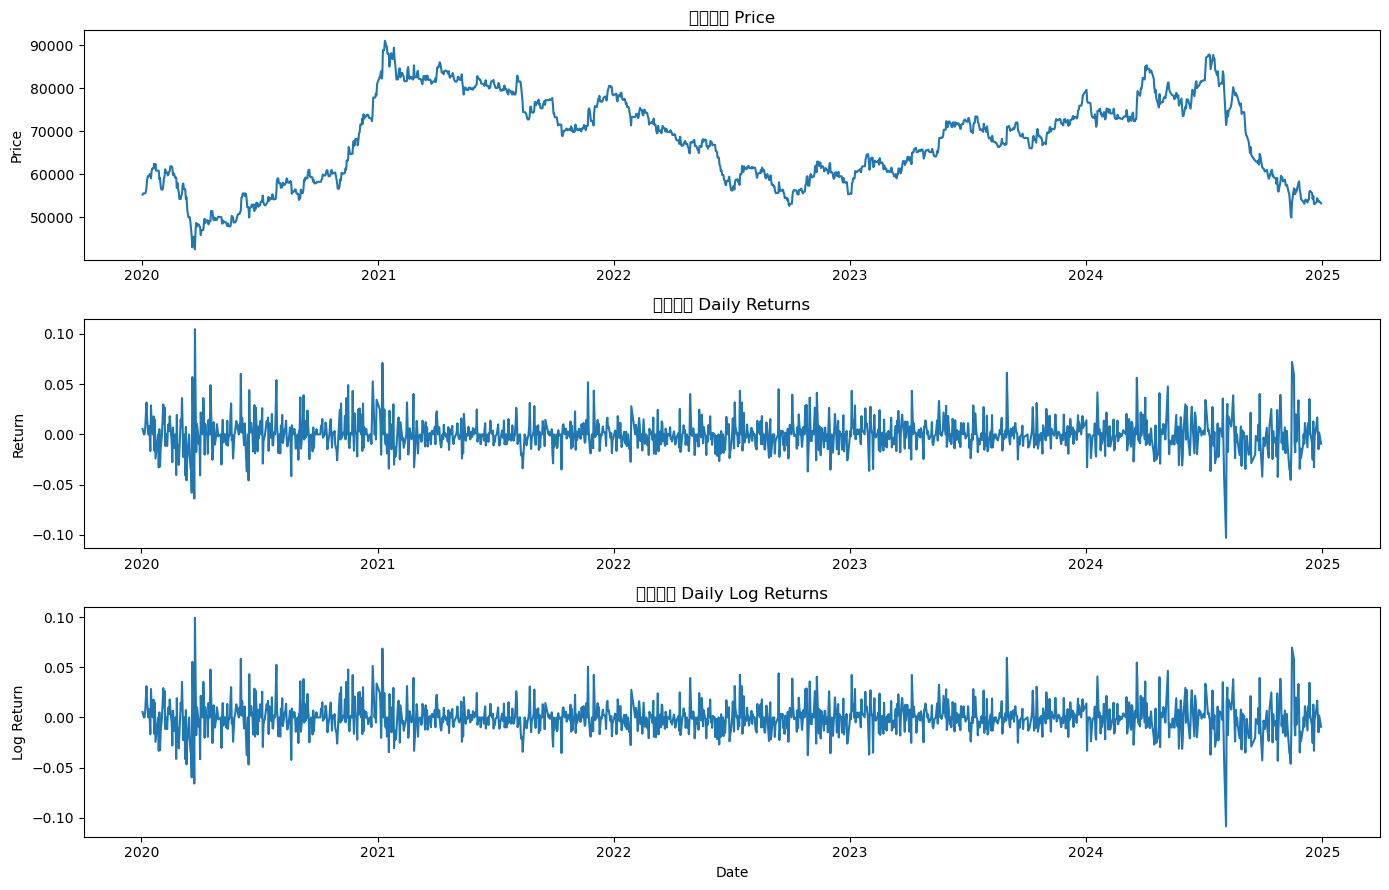

==== 삼성전자 통계 요약 ====
                 Price       Return    LogReturn
count      1455.000000  1454.000000  1454.000000
mean      67760.446735     0.000094    -0.000025
std       10057.509366     0.015510     0.015468
min       42500.000000    -0.103015    -0.108716
25%       59500.000000    -0.007692    -0.007722
50%       68400.000000     0.000000     0.000000
75%       75600.000000     0.006667     0.006645
max       91000.000000     0.104706     0.099579
skewness     -0.038822     0.440125     0.291784
kurtosis     -0.928584     4.557038     4.543326




/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyph 45320 (\N{HANGUL SYLLABLE NEO}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyph 49556 (\N{HANGUL SYLLABLE SOL}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyph 47336 (\N{HANGUL SYLLABLE RU}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyp

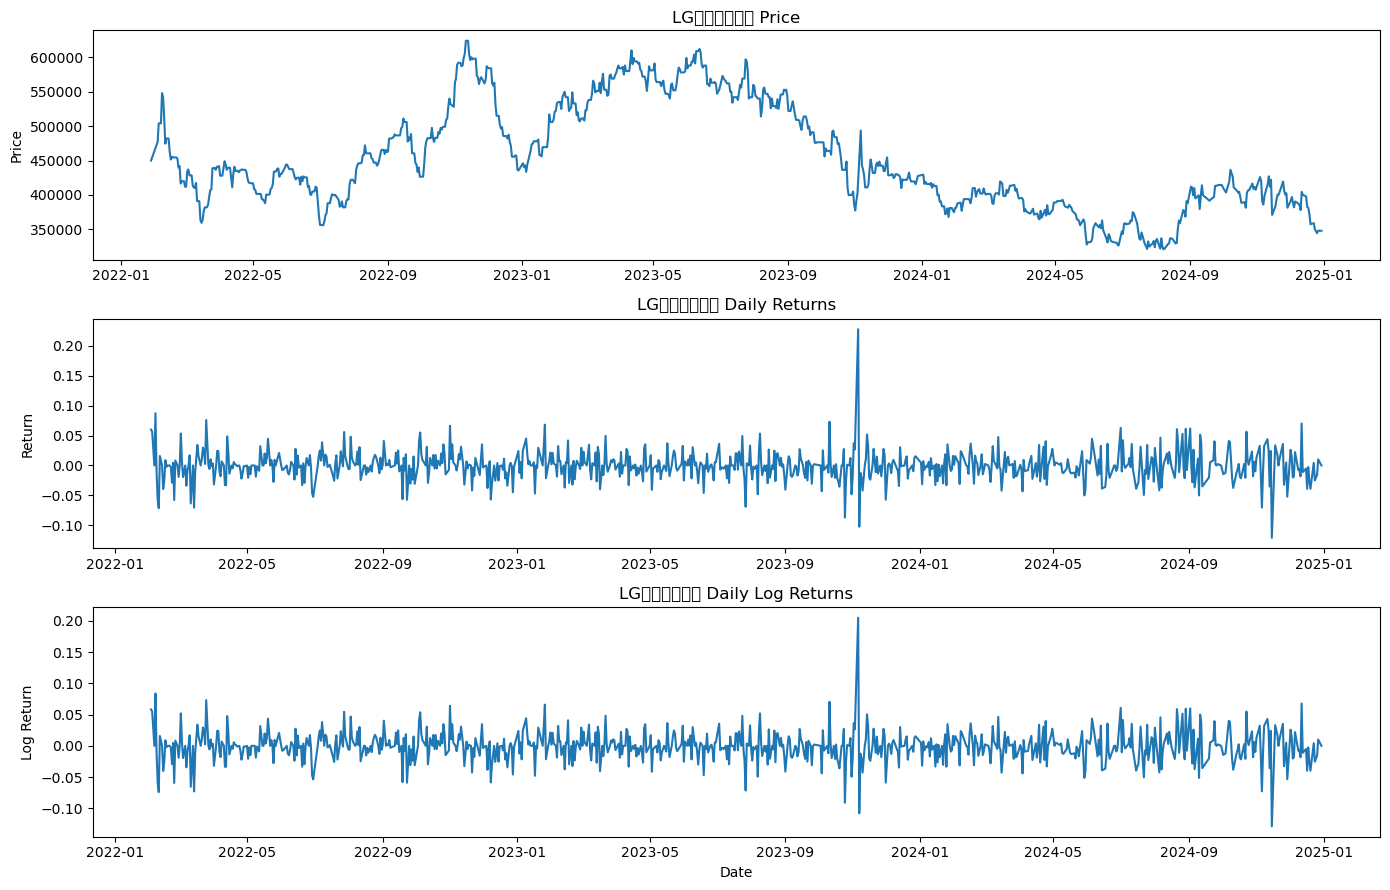

==== LG에너지솔루션 통계 요약 ====
                  Price      Return   LogReturn
count        821.000000  820.000000  820.000000
mean      455763.702801   -0.000018   -0.000313
std        76016.968247    0.024446    0.024273
min       321000.000000   -0.120853   -0.128803
25%       399500.000000   -0.011878   -0.011949
50%       436500.000000    0.000000    0.000000
75%       525000.000000    0.010519    0.010464
max       624000.000000    0.227612    0.205071
skewness       0.367696    0.840258    0.461865
kurtosis      -0.993122   10.415366    7.888876




/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from current font.
  plt.tight_layout()
/opt/homebrew/anaconda3/envs/my_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/anaconda3/envs/my_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/anacon

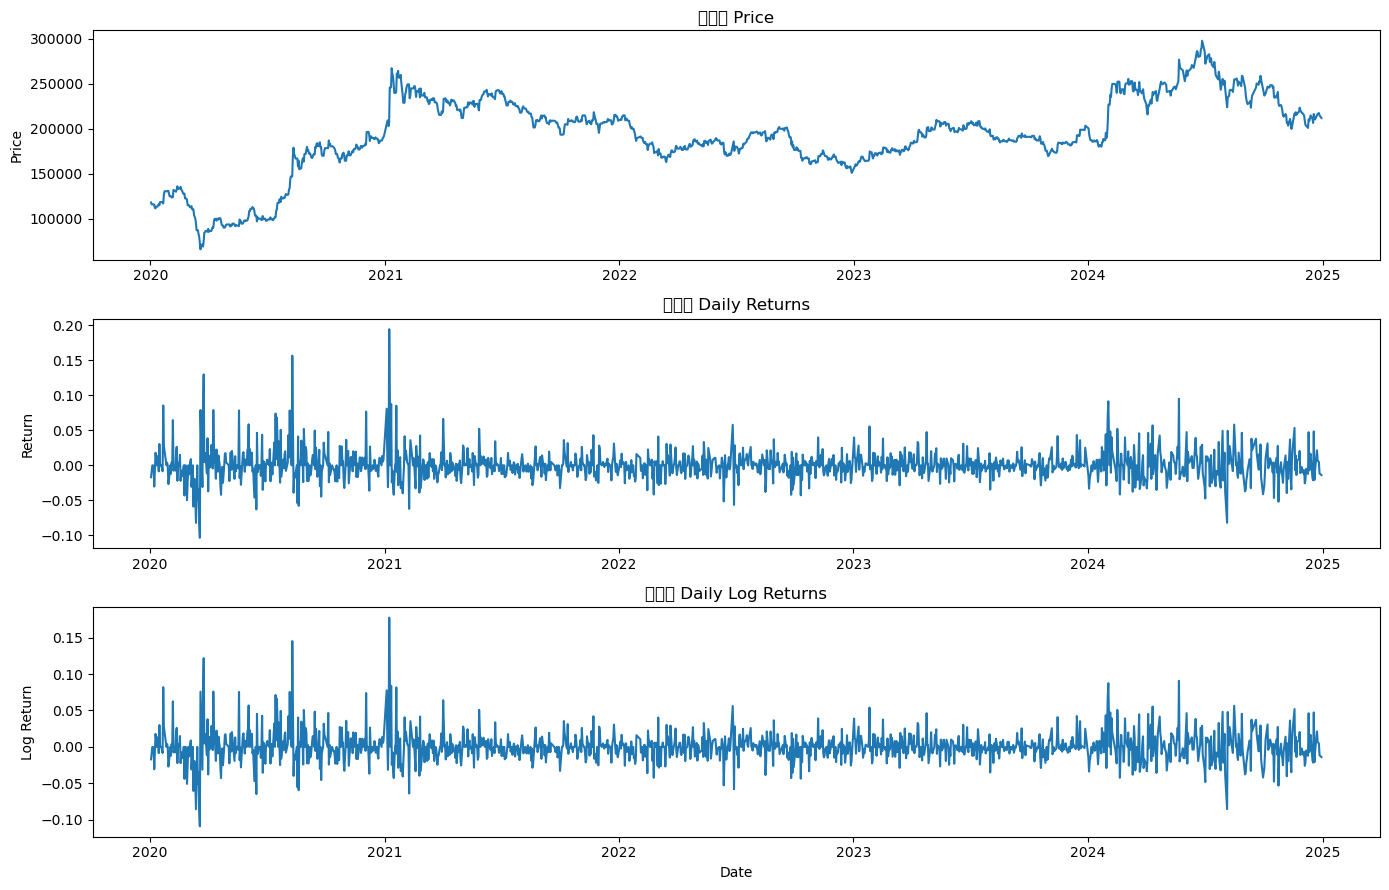

==== 현대차 통계 요약 ====
                  Price       Return    LogReturn
count       1443.000000  1442.000000  1442.000000
mean      191276.368676     0.000619     0.000406
std        42516.844049     0.020800     0.020524
min        65900.000000    -0.103401    -0.109147
25%       173350.000000    -0.008997    -0.009038
50%       190800.000000     0.000000     0.000000
75%       218500.000000     0.008020     0.007988
max       298000.000000     0.194175     0.177455
skewness      -0.563476     1.452426     1.139859
kurtosis       0.334794    10.946566     9.072414




/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyph 45348 (\N{HANGUL SYLLABLE NE}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyph 48260 (\N{HANGUL SYLLABLE BEO}) missing from current font.
  plt.tight_layout()
/opt/homebrew/anaconda3/envs/my_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 45348 (\N{HANGUL SYLLABLE NE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/anaconda3/envs/my_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/anaconda3/envs/

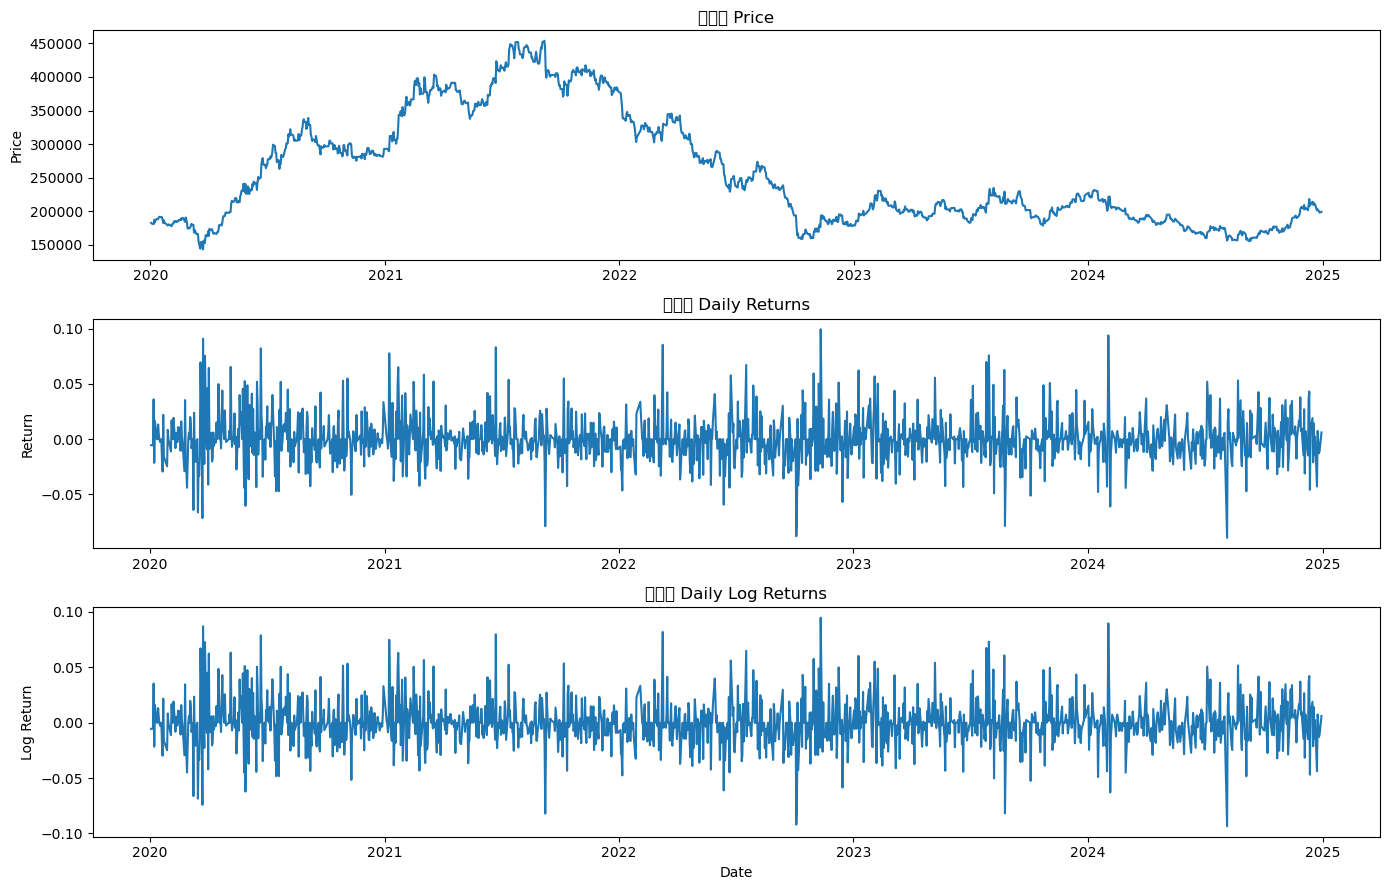

==== 네이버 통계 요약 ====
                  Price       Return    LogReturn
count       1443.000000  1442.000000  1442.000000
mean      258794.455994     0.000272     0.000060
std        82322.109122     0.020668     0.020589
min       143000.000000    -0.089265    -0.093503
25%       190800.000000    -0.010739    -0.010797
50%       223500.000000     0.000000     0.000000
75%       318000.000000     0.008889     0.008850
max       454000.000000     0.099432     0.094794
skewness       0.699858     0.449360     0.304420
kurtosis      -0.802071     2.896470     2.809210




/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from current font.
  plt.tight_layout()
/var/folders/19/qmc_r3sj18x1309vcb03xtr00000gn/T/ipykernel_97237/106510328.py:52: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from current font.
  plt.tight_layout()
/opt/homebrew/anaconda3/envs/my_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/anaconda3/envs/my_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


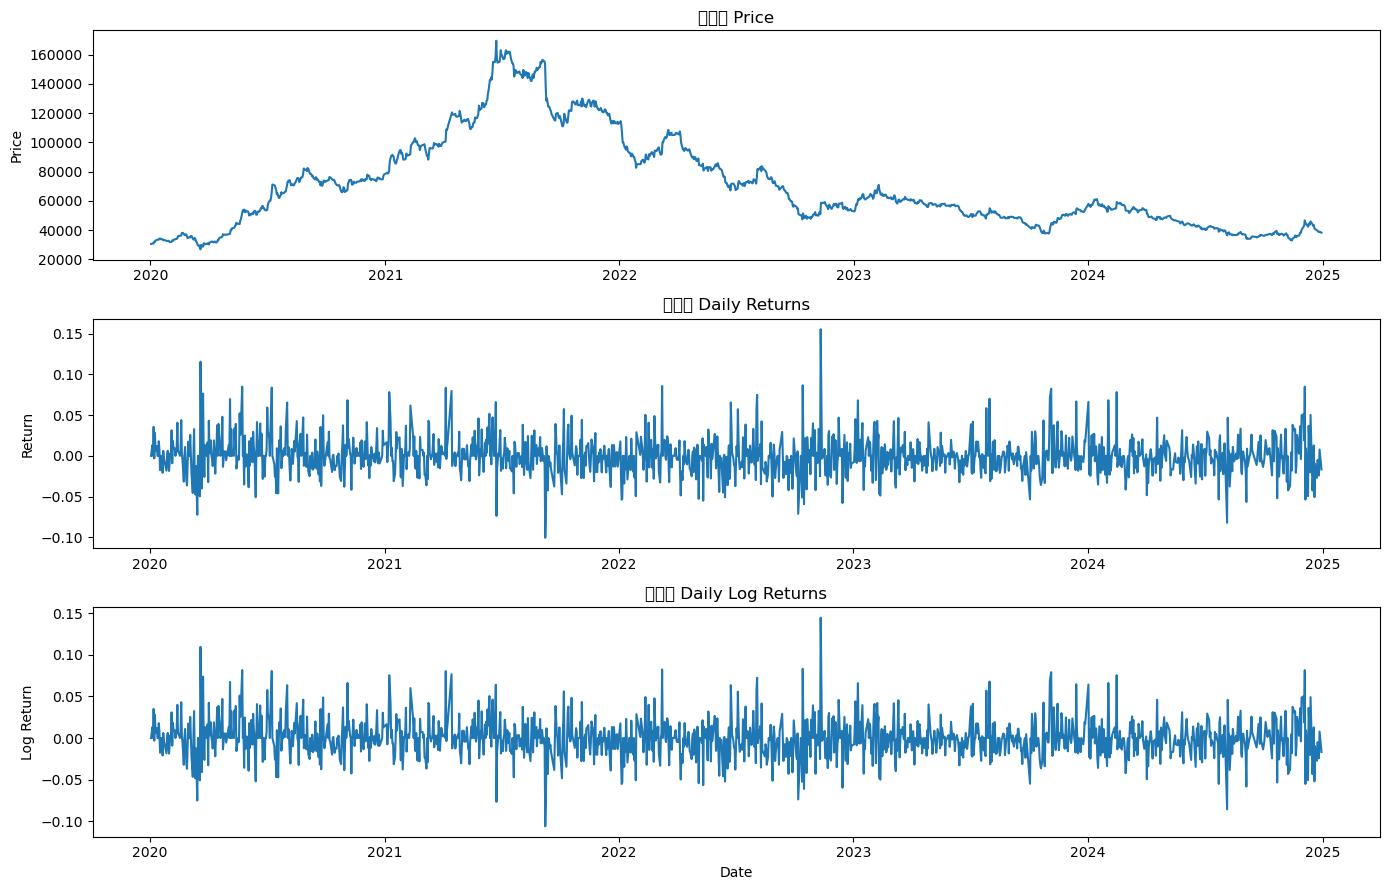

==== 카카오 통계 요약 ====
                  Price       Return    LogReturn
count       1447.000000  1446.000000  1446.000000
mean       71117.829993     0.000407     0.000156
std        31748.357250     0.022551     0.022402
min        26800.000000    -0.100649    -0.106082
25%        48700.000000    -0.011950    -0.012022
50%        60500.000000     0.000000     0.000000
75%        89700.000000     0.009322     0.009279
max       169500.000000     0.155512     0.144543
skewness       1.011043     0.676431     0.504384
kurtosis       0.271871     3.737344     3.296625




In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 종목별 파일 불러오기
df_samsung = pd.read_csv('삼성전자.csv')
df_lg = pd.read_csv('LG에너지솔루션.csv')
df_hyundai = pd.read_csv('현대차.csv')
df_naver = pd.read_csv('naver.csv')
df_kakao = pd.read_csv('kakao.csv')

# 2. 데이터 전처리 함수
def preprocess(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df['Price'] = df['Price'].replace(',', '', regex=True).astype(float)
    df = df.sort_values('Date').reset_index(drop=True)
    df['Return'] = df['Price'].pct_change()
    df['LogReturn'] = np.log(df['Price'] / df['Price'].shift(1))
    df['Target'] = (df['Return'] > 0).astype(int)
    return df

# 3. 모든 종목 전처리
df_samsung = preprocess(df_samsung)
df_lg = preprocess(df_lg)
df_hyundai = preprocess(df_hyundai)
df_naver = preprocess(df_naver)
df_kakao = preprocess(df_kakao)

# 4. 분석 함수 정의
def analyze_stock(df, name):
    plt.figure(figsize=(14, 9))

    # 가격 그래프
    plt.subplot(3, 1, 1)
    plt.plot(df['Date'], df['Price'])
    plt.title(f'{name} Price')
    plt.ylabel('Price')

    # 수익률 그래프
    plt.subplot(3, 1, 2)
    plt.plot(df['Date'], df['Return'])
    plt.title(f'{name} Daily Returns')
    plt.ylabel('Return')

    # 로그 수익률 그래프
    plt.subplot(3, 1, 3)
    plt.plot(df['Date'], df['LogReturn'])
    plt.title(f'{name} Daily Log Returns')
    plt.ylabel('Log Return')
    plt.xlabel('Date')

    plt.tight_layout()
    plt.show()

    # 기초 통계 요약
    stats = df[['Price', 'Return', 'LogReturn']].describe()
    stats.loc['skewness'] = df[['Price', 'Return', 'LogReturn']].skew()
    stats.loc['kurtosis'] = df[['Price', 'Return', 'LogReturn']].kurt()

    print(f"==== {name} 통계 요약 ====")
    print(stats)
    print("\n" + "="*80 + "\n")

# 5. 종목별 분석
analyze_stock(df_samsung, "삼성전자")
analyze_stock(df_lg, "LG에너지솔루션")
analyze_stock(df_hyundai, "현대차")
analyze_stock(df_naver, "네이버")
analyze_stock(df_kakao, "카카오")


삼성전자와 LG에너지 솔루션의 경우 2번과 동일합니다.


## 현대차 분석
### Price (가격)
평균: 191,276

표준편차: 42,517 (→ 평균 대비 약 22.2% 변동폭 (42,517 ÷ 191,276 ≈ 22.2%))

최소/최대: 65,900 ~ 298,000 (→ 약 4.52배 상승 구간 존재)

중앙값: 190,800 (→ 평균보다 약간 낮음, 약간 오른쪽 꼬리 느낌)

왜도 (skewness): -0.5635
→ 왼쪽 꼬리 (극단적 하락 사례가 많다.)

첨도 (kurtosis): +0.3348
→ 정규분포보다 약간 뾰족한 형태 (극단적 이벤트가 조금 존재)


현대차 주가는 장기적으로 꽤 넓게 움직이며,
극단적 하락 이벤트(급락)가 상대적으로 눈에 띄게 발생하는 편이다.

### Return (일반 수익률)
평균: +0.0619% (소폭 상승)

표준편차: 2.08% (1일 평균 변동폭)

최대 상승: +19.42%

최대 하락: -10.34%

왜도 (skewness): +1.4524
→ 강한 오른쪽 꼬리 (급등 사례가 매우 많다)

첨도 (kurtosis): +10.9466
→ 극단적 변동이 매우 잦은 Fat Tail 분포


현대차 수익률은 급등 이벤트가 굉장히 빈번하며,
극단적 상승 사건이 자주 발생하는 고변동 패턴이다.

### LogReturn (로그 수익률)
평균: +0.0406%

표준편차: 2.05%

최대 상승: +17.75%

최대 하락: -10.91%

왜도 (skewness): +1.1399
→ 오른쪽 꼬리 (급등 쪽)

첨도 (kurtosis): +9.0724
→ 역시 Fat Tail 분포


로그 수익률에서도 급등 편향과 급격한 변동성이 매우 뚜렷하다.

## 네이버 분석
### Price (가격)
평균: 258,794

표준편차: 82,322 (→ 평균 대비 약 31.8% 변동폭 (82,322 ÷ 258,794 ≈ 31.8%))

최소/최대: 143,000 ~ 454,000 (→ 약 3.17배 상승 구간 존재)

중앙값: 223,500 (→ 평균보다 낮음, 오른쪽 꼬리 느낌)

왜도 (skewness): +0.6999
→ 오른쪽 꼬리 (고가 사례가 많다)

첨도 (kurtosis): -0.8021
→ 정규분포보다 평평한 형태 (극단적 가격은 많지 않음)


네이버 주가는 상대적으로 넓게 퍼져 있으며,
극단적 고가(급등) 사례가 약간 존재한다.

### Return (일반 수익률)
평균: +0.0272% (미세한 상승)

표준편차: 2.07%

최대 상승: +9.94%

최대 하락: -8.93%

왜도 (skewness): +0.4494
→ 오른쪽 꼬리 (급등 쪽 약간 우세)

첨도 (kurtosis): +2.8965
→ Fat Tail 경향 존재 (극단적 이벤트 많음)


네이버 수익률은 급등 가능성이 약간 높고,
급변성도 존재하지만 삼성/현대차보다는 상대적으로 약하다.

### LogReturn (로그 수익률)
평균: +0.0060%

표준편차: 2.06%

최대 상승: +9.48%

최대 하락: -9.35%

왜도 (skewness): +0.3044
→ 오른쪽 꼬리

첨도 (kurtosis): +2.8092
→ Fat Tail 경향 있음


로그 수익률에서도 급등 사례가 약간 많고,
급격한 가격 변동 가능성은 존재한다.



## 카카오 분석
### Price (가격)
평균: 71,118

표준편차: 31,748 (→ 평균 대비 약 44.6% 변동폭 (31,748 ÷ 71,118 ≈ 44.6%))

최소/최대: 26,800 ~ 169,500 (→ 약 6.32배 상승 구간 존재)

중앙값: 60,500 (→ 평균보다 낮음, 오른쪽 꼬리 느낌)

왜도 (skewness): +1.0110
→ 오른쪽 꼬리 (극단적 고가 사례가 매우 많음)

첨도 (kurtosis): +0.2719
→ 정규분포보다 약간 뾰족한 형태


카카오 주가는 변동성이 매우 크고,
급등 사례가 상당히 많다.

### Return (일반 수익률)
평균: +0.0407% (미세한 상승)

표준편차: 2.26%

최대 상승: +15.55%

최대 하락: -10.06%

왜도 (skewness): +0.6764
→ 오른쪽 꼬리 (급등 쪽 강함)

첨도 (kurtosis): +3.7373
→ Fat Tail 현상 존재


카카오 수익률은 급등 가능성이 뚜렷하고,
극단적 변동성(급변)이 자주 발생하는 편이다.

### LogReturn (로그 수익률)
평균: +0.0156%

표준편차: 2.24%

최대 상승: +14.45%

최대 하락: -10.61%

왜도 (skewness): +0.5044
→ 오른쪽 꼬리

첨도 (kurtosis): +3.2966
→ Fat Tail 현상 유지


로그 수익률에서도 급등 편향과 급격한 변동성이 명확하다.

### 분석 B

In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. 파일 불러오기
df_samsung = pd.read_csv('삼성전자.csv')
df_lg = pd.read_csv('LG에너지솔루션.csv')
df_hyundai = pd.read_csv('현대차.csv')
df_naver = pd.read_csv('naver.csv')
df_kakao = pd.read_csv('kakao.csv')

# 2. 날짜 변환
for df in [df_samsung, df_lg, df_hyundai, df_naver, df_kakao]:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Price'] = df['Price'].replace(',', '', regex=True).astype(float)

# 3. 날짜 기준 정렬
for df in [df_samsung, df_lg, df_hyundai, df_naver, df_kakao]:
    df.sort_values('Date', inplace=True)
    df.reset_index(drop=True, inplace=True)

# 4. 병합
df = df_samsung[['Date', 'Price']].copy()
df = df.rename(columns={'Price': 'Price_Samsung'})

df = pd.merge(df, df_lg[['Date', 'Price']].rename(columns={'Price': 'Price_LG'}), on='Date', how='inner')
df = pd.merge(df, df_hyundai[['Date', 'Price']].rename(columns={'Price': 'Price_Hyundai'}), on='Date', how='inner')
df = pd.merge(df, df_naver[['Date', 'Price']].rename(columns={'Price': 'Price_Naver'}), on='Date', how='inner')
df = pd.merge(df, df_kakao[['Date', 'Price']].rename(columns={'Price': 'Price_Kakao'}), on='Date', how='inner')

# 5. Feature 생성
for col in ['Price_Samsung', 'Price_LG', 'Price_Hyundai', 'Price_Naver', 'Price_Kakao']:
    df[f'{col}_Return'] = df[col].pct_change()
    df[f'{col}_LogReturn'] = np.log(df[col] / df[col].shift(1))
    df[f'{col}_MA5'] = df[col].rolling(window=5).mean()
    df[f'{col}_MA20'] = df[col].rolling(window=20).mean()
    df[f'{col}_MA_diff'] = df[f'{col}_MA5'] - df[f'{col}_MA20']
    df[f'{col}_Volatility20'] = df[f'{col}_Return'].rolling(window=20).std()
    df[f'{col}_Target'] = (df[col].shift(-1) > df[col]).astype(int)

# 6. Feature와 Target 설정
feature_cols = []
target_cols = []
for col in ['Price_Samsung', 'Price_LG', 'Price_Hyundai', 'Price_Naver', 'Price_Kakao']:
    feature_cols += [f'{col}_Return', f'{col}_LogReturn', f'{col}_MA5', f'{col}_MA20', f'{col}_MA_diff', f'{col}_Volatility20']
    target_cols.append(f'{col}_Target')

X = df[feature_cols].dropna()
y = df.loc[X.index, target_cols]

# 7. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 8. 모델 정의
models = {
    'RandomForest': MultiOutputClassifier(RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)),
    'LogisticRegression': MultiOutputClassifier(LogisticRegression(max_iter=1000, C=0.5)),
    'XGBoost': MultiOutputClassifier(XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, eval_metric='logloss', random_state=42))
}

# 9. 결과 저장 및 출력
results = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[model_name] = {}
    for idx, target in enumerate(target_cols):
        results[model_name][target] = {
            'Accuracy': accuracy_score(y_test.iloc[:, idx], y_pred[:, idx]),
            'Confusion Matrix': confusion_matrix(y_test.iloc[:, idx], y_pred[:, idx]),
            'Classification Report': classification_report(y_test.iloc[:, idx], y_pred[:, idx])
        }

# 10. 출력
for model_name, model_results in results.items():
    print(f"\n=== {model_name} 결과 ===")
    for stock, metrics in model_results.items():
        print(f"\n[{stock}]")
        print(f"Accuracy: {metrics['Accuracy']:.4f}")
        print("Confusion Matrix:\n", metrics['Confusion Matrix'])
        print("Classification Report:\n", metrics['Classification Report'])



=== RandomForest 결과 ===

[Price_Samsung_Target]
Accuracy: 0.5890
Confusion Matrix:
 [[120  22]
 [ 75  19]]
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.85      0.71       142
           1       0.46      0.20      0.28        94

    accuracy                           0.59       236
   macro avg       0.54      0.52      0.50       236
weighted avg       0.55      0.59      0.54       236


[Price_LG_Target]
Accuracy: 0.5551
Confusion Matrix:
 [[109  35]
 [ 70  22]]
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.76      0.67       144
           1       0.39      0.24      0.30        92

    accuracy                           0.56       236
   macro avg       0.50      0.50      0.49       236
weighted avg       0.52      0.56      0.53       236


[Price_Hyundai_Target]
Accuracy: 0.5932
Confusion Matrix:
 [[126  27]
 [ 69  14]]
Classification Report:
      

## 결과 분석
### 1. Random Forest의 경우
#### Samsung전자 정확도: 58.90%

하락(0) 예측은 꽤 잘함 (Recall 85%)

상승(1) 예측은 약함 (Recall 20%)

전체적으로 하락만 잘 맞추는 패턴.

#### LG에너지솔류션 정확도: 55.51%
하락(0) 예측은 괜찮음 (Recall 76%)

상승(1) 예측은 매우 약함 (Recall 24%)

#### Hyundai 정확도: 59.32%
하락(0) 예측은 양호 (Recall 82%)

상승(1) 예측은 약함 (Recall 17%)

#### Naver 정확도: 61.44%
하락(0) 예측은 잘함 (Recall 86%)

상승(1) 예측은 약함 (Recall 20%)

#### Kakao 정확도: 57.63%
하락(0) 예측은 양호 (Recall 82%)

상승(1) 예측은 약함 (Recall 16%)

### 요약
Random Forest는 전반적으로 하락(0) 예측에 강하고, 상승(1) 예측은 약하다.
특히 상승 포착이 매우 어렵다는 한계가 뚜렷하다.

### 2. Logistic Regression의 경우
#### Samsung전자 정확도: 61.02%
하락만 무조건 예측 (0 클래스 위주)

#### LG에너지솔류션 정확도: 56.78%
하락(0)만 예측하려는 경향 강함

상승(1) 예측 거의 실패 (Recall 22%)

#### Hyundai 정확도: 55.93%
하락(0)만 잘 맞추고, 상승(1) 예측력 낮음 (Recall 20%)

#### Naver 정확도: 64.83%
하락(0) 예측 매우 강함 (Recall 93%)

상승(1) 예측은 매우 약함 (Recall 17%)

#### Kakao 정확도: 59.75%
하락(0)만 무조건 예측, 상승(1) 거의 무시.

### 요약
Logistic Regression은 기본적으로 하락(0)만 예측하려는 구조를 가지고 있으며,
상승(1)을 제대로 포착하지 못한다.
→ 구조적 한계 때문에 환율 데이터 추가나 Feature 추가로 개선하기 어렵다.

### 3. XGBoost의 경우
#### Samsung전자 정확도: 54.66%
하락/상승을 균형있게 예측하려 시도.

하지만 전체적인 정확도는 낮음.

#### LG에너지솔루션 정확도: 50.42%
하락(0) 예측은 그럭저럭 (Recall 62%)

상승(1) 예측은 약함 (Recall 32%)

#### Hyundai 정확도: 55.51%
하락/상승 모두 약간 포착하지만 정확도 낮음.

#### Naver 정확도: 56.78%
하락은 어느정도 맞추지만 상승은 약함.

#### Kakao 정확도: 56.78%
상승 포착력이 다소 약하지만 균형은 맞추려는 경향.

### 요약
XGBoost는 유일하게 상승/하락 둘 다 잡으려는 시도를 하며,
가장 자연스러운 분포를 보인다.
하지만 정확도는 50~57% 수준이라 여전히 신뢰성이 낮다.

### 분석 C

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. 파일 불러오기
df_samsung = pd.read_csv('삼성전자.csv')
df_lg = pd.read_csv('LG에너지솔루션.csv')
df_hyundai = pd.read_csv('현대차.csv')
df_naver = pd.read_csv('naver.csv')
df_kakao = pd.read_csv('kakao.csv')
df_usdkrw = pd.read_csv('usdkrw.csv')

# 2. 날짜 변환
for df in [df_samsung, df_lg, df_hyundai, df_naver, df_kakao, df_usdkrw]:
    df['Date'] = pd.to_datetime(df['Date'])

# 3. Price 변환 (숫자로 변환)
for df in [df_samsung, df_lg, df_hyundai, df_naver, df_kakao, df_usdkrw]:
    df['Price'] = df['Price'].replace(',', '', regex=True).astype(float)

# 4. 날짜 기준 정렬
for df in [df_samsung, df_lg, df_hyundai, df_naver, df_kakao, df_usdkrw]:
    df.sort_values('Date', inplace=True)
    df.reset_index(drop=True, inplace=True)

# 5. 병합 (Date 기준)
df = df_samsung[['Date', 'Price']].rename(columns={'Price': 'Price_Samsung'})
df['Price_LG'] = df_lg['Price']
df['Price_Hyundai'] = df_hyundai['Price']
df['Price_Naver'] = df_naver['Price']
df['Price_Kakao'] = df_kakao['Price']
df['USD_KRW'] = df_usdkrw['Price']

# 6. 환율 결측치 보정 (전날 값으로 채우기)
df['USD_KRW'] = df['USD_KRW'].fillna(method='ffill')

# 7. Feature 생성 (종목 + 환율)
for col in ['Price_Samsung', 'Price_LG', 'Price_Hyundai', 'Price_Naver', 'Price_Kakao', 'USD_KRW']:
    df[f'{col}_Return'] = df[col].pct_change()
    df[f'{col}_LogReturn'] = np.log(df[col] / df[col].shift(1))
    df[f'{col}_MA5'] = df[col].rolling(5).mean()
    df[f'{col}_MA20'] = df[col].rolling(20).mean()
    df[f'{col}_MA_diff'] = df[f'{col}_MA5'] - df[f'{col}_MA20']
    df[f'{col}_Volatility20'] = df[f'{col}_Return'].rolling(20).std()

# 8. Target 생성 (종목만, 환율은 Target 없음)
for col in ['Price_Samsung', 'Price_LG', 'Price_Hyundai', 'Price_Naver', 'Price_Kakao']:
    df[f'{col}_Target'] = (df[col].shift(-1) > df[col]).astype(int)

# 9. Feature/Target 설정
feature_cols = []
target_cols = []

# 종목 feature
for stock in ['Samsung', 'LG', 'Hyundai', 'Naver', 'Kakao']:
    feature_cols.extend([
        f'Price_{stock}_Return', f'Price_{stock}_LogReturn',
        f'Price_{stock}_MA5', f'Price_{stock}_MA20',
        f'Price_{stock}_MA_diff', f'Price_{stock}_Volatility20'
    ])
    target_cols.append(f'Price_{stock}_Target')

# 환율 feature (Price_ 없이)
feature_cols.extend([
    'USD_KRW_Return', 'USD_KRW_LogReturn',
    'USD_KRW_MA5', 'USD_KRW_MA20',
    'USD_KRW_MA_diff', 'USD_KRW_Volatility20'
])

# 10. Feature/Target 데이터셋 만들기
X = df[feature_cols].dropna()
y = df.loc[X.index, target_cols]

# 11. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 12. 모델 정의
models = {
    'RandomForest': MultiOutputClassifier(RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)),
    'LogisticRegression': MultiOutputClassifier(LogisticRegression(max_iter=1000, C=0.5)),
    'XGBoost': MultiOutputClassifier(XGBClassifier(n_estimators=50, max_depth=4, learning_rate=0.1, eval_metric='logloss', random_state=42))
}

# 13. 결과 저장 및 출력
results = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = {}
    for i, stock in enumerate(['Samsung', 'LG', 'Hyundai', 'Naver', 'Kakao']):
        metrics[stock] = {
            'Accuracy': accuracy_score(y_test.iloc[:, i], y_pred[:, i]),
            'Confusion Matrix': confusion_matrix(y_test.iloc[:, i], y_pred[:, i]),
            'Classification Report': classification_report(y_test.iloc[:, i], y_pred[:, i])
        }
    results[model_name] = metrics

# 14. 결과 출력
for model_name, model_metrics in results.items():
    print(f"\n=== {model_name} 결과 ===")
    for stock, metrics in model_metrics.items():
        print(f"\n[{stock}]")
        print(f"Accuracy: {metrics['Accuracy']:.4f}")
        print("Confusion Matrix:\n", metrics['Confusion Matrix'])
        print("Classification Report:\n", metrics['Classification Report'])



=== RandomForest 결과 ===

[Samsung]
Accuracy: 0.5768
Confusion Matrix:
 [[134  17]
 [ 85   5]]
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.89      0.72       151
           1       0.23      0.06      0.09        90

    accuracy                           0.58       241
   macro avg       0.42      0.47      0.41       241
weighted avg       0.47      0.58      0.49       241


[LG]
Accuracy: 0.5519
Confusion Matrix:
 [[117  16]
 [ 92  16]]
Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.88      0.68       133
           1       0.50      0.15      0.23       108

    accuracy                           0.55       241
   macro avg       0.53      0.51      0.46       241
weighted avg       0.53      0.55      0.48       241


[Hyundai]
Accuracy: 0.5643
Confusion Matrix:
 [[131  17]
 [ 88   5]]
Classification Report:
               precision    recall  f1-score 

## 결과 분석
### 1. Random Forest의 경우
#### Samsung전자
정확도: 57.68%

하락(0) 예측은 매우 강함 (Recall 89%)

상승(1) 예측은 매우 약함 (Recall 6%)

#### LG에너지솔루션
정확도: 55.19%

하락(0) 예측은 꽤 잘함 (Recall 88%)

상승(1) 예측은 약함 (Recall 15%)

#### Hyundai
정확도: 56.43%

하락(0) 예측은 강함 (Recall 89%)

상승(1) 예측은 매우 약함 (Recall 5%)

#### Naver
정확도: 60.17%

하락(0) 예측은 매우 잘함 (Recall 92%)

상승(1) 예측은 약함 (Recall 8%)

#### Kakao
정확도: 63.49%

하락(0) 예측은 좋음 (Recall 85%)

상승(1) 예측은 31%로 약간 개선

### 요약
RandomForest는 여전히 하락(0) 위주로 강한 예측을 보임.

특히 카카오(Kakao) 에서는 상승(1) (Recall이 31%)로 상대적으로 가장 높게 개선됨.

전체적으로 환율 등 추가 변수를 넣어도 구조적 특성은 유지.

상승 포착 능력은 극히 제한적이나 조금은 개선된 종목도 존재.

### 2. Logistic Regression의 경우
#### Samsung전자
정확도: 63.49%

거의 무조건 하락(0)만 예측 (Recall 100%)

상승(1) 포착 거의 불가 (Recall 2%)

#### LG애너지솔루션
정확도: 51.45%

하락(0) 위주 예측 (Recall 80%)

상승(1) 예측 약함 (Recall 16%)

#### Hyundai
정확도: 60.17%

하락(0)만 강하게 예측 (Recall 95%)

상승(1) 포착 거의 불가 (Recall 4%)

#### Naver
정확도: 62.66%

하락(0) 예측 매우 강함 (Recall 94%)

상승(1) 예측 매우 약함 (Recall 11%)

#### Kakao
정확도: 60.58%

하락(0) 예측 강함 (Recall 81%)

상승(1) 예측은 다소 약함 (Recall 29%)

### 요약
Logistic Regression은 여전히 하락(0)만 예측하는 경향이 뚜렷.

환율 데이터 추가해도 모델 구조상 개선 불가.

상승(1) 포착은 여전히 거의 불가능한 수준.

### 3. XGBoost의 경우
#### Samsung전자
정확도: 54.36%

하락(0) 예측은 준수 (Recall 79%)

상승(1) 예측은 약함 (Recall 12%)

#### LG에너지솔루션
정확도: 52.28%

하락(0) 예측은 보통 (Recall 72%)

상승(1) 예측은 약함 (Recall 28%)

#### Hyundai
정확도: 56.43%

하락(0) 예측은 괜찮음 (Recall 76%)

상승(1) 포착 약함 (Recall 26%)

#### Naver
정확도: 58.09%

하락(0) 예측은 양호 (Recall 81%)

상승(1) 포착은 약함 (Recall 21%)

#### Kakao
정확도: 65.98%

하락(0) 예측은 매우 좋음 (Recall 84%)

상승(1) 포착은 상대적으로 개선 (Recall 39%)

### 요약
XGBoost는 여전히 상승/하락 모두 잡으려는 시도를 보임.

카카오(Kakao) 에서 상승 포착 (Recall 39%)로 꽤 좋은 개선.

하지만 대부분 종목에서 상승(1) 예측은 여전히 약함.

전체 정확도는 50~66% 수준 → 여전히 안정적 투자에는 한계.

### 각각의 분류기에 결과에 대한 전체적인 분석
Random Forest의 경우 환율 추가로 상승 포착력이 소폭 향상되었습니다. 특히 카카오에서는 상당한 개선이 되지만 전체적인 예측 한계는 여전이 있습니다..

Logistic Regression의 경우 모든 실험에서 한 방향으로만 예측했기 때문에 구조적 한계로 개선 불가했다 상승(1) 예측 실패을 실패했습니다.

XGBoost의 경우 환율 추가 시 성과는 종목별로 차이가 발생했습니다. 특히 카카오는 가장 긍정적(정확도 66%, 상승 포착 39%)으로 나타났다. 하지만 다른 종목은 여전히 약한 모습을 보였습니다.

### 최종적으로 이 결과를 통해 느낀 것은
삼성전자, LG에너지솔루션 수준에서는 환율 데이터가 약간 긍정적인 역할을 하지만 전반적 성능은 큰 개선 없이 제한적라는 것이었고, 다만, 종목 수를 늘리고 (특히 카카오 같이 변동성이 높은 종목) 개별화된 분석을 하면 일부 종목에서는 상승 포착이 확실히 개선되었다는 것을 보아, 비교분석하는 종목을 잘 선정하는 것이 중요하다는 점을 알게 되었습니다.

그리고 Logistic Regression은 모든 결과에서 하락으로만 예측했기 때문에 현재 구조에서는 쓸 수 없는 모델이라는 점입니다.

더 나은 결과를 위해서는 RandomForest와 XGBoost를 개선하거나, 새심한 새로운 종목 데이터의 선정, 새로운 Feature (예: 금리, 외국인 순매수 데이터 등) 추가가 필요할 것으로 생각되어집니다.